In [1]:
import os
import re
import numpy as np            
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
sc.set_figure_params(dpi=100, color_map='viridis', fontsize=6)
sc.settings.verbosity=2
sc.settings.n_jobs=1
sc.logging.print_versions()

-----
anndata     0.10.9
scanpy      1.10.3
-----
PIL                         11.2.1
anyio                       NA
arrow                       1.3.0
asciitree                   NA
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
babel                       2.17.0
backports                   NA
certifi                     2025.04.26
charset_normalizer          3.4.1
cloudpickle                 3.1.1
comm                        0.2.2
cycler                      0.12.1
cython_runtime              NA
dask                        2024.8.0
dateutil                    2.9.0.post0
debugpy                     1.8.14
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.2.0
fastjsonschema              NA
fqdn                        NA
h5py                        3.13.0
idna                        3.10
igraph                      0.11.8
importlib_resources         NA
i

/home/liuxiaodongLab/jiangjing/.local/lib/python3.9/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [2]:
adata = sc.read_h5ad("new_umap_dim18_spread2.5_mindist0.7_celltypes_250416.h5ad")

In [3]:
# 定义要分析的多个细胞类型
target_types = ['Rgl1-like', 'DA progenitor-FABP7', 'DA progenitor-CHRNA6 high','DA progenitor-CHRNA6 low','DA progenitor-terminal',
               'Immature DA','Mature DA']  # 替换为你的目标类型

# 提取多类别子集（保留交集基因）
adata_sub = adata[adata.obs['human_celltypes_250416'].isin(target_types), :].copy()

# 检查细胞数量分布
print(adata_sub.obs['human_celltypes_250416'].value_counts())

human_celltypes_250416
DA progenitor-FABP7          4886
DA progenitor-terminal       2011
Rgl1-like                    1425
DA progenitor-CHRNA6 low      957
DA progenitor-CHRNA6 high     865
Immature DA                   756
Mature DA                     132
Name: count, dtype: int64


In [4]:
# 2. 创建重命名映射字典（示例）
cluster_rename = {
    'DA progenitor-CHRNA6 low': 'DA progenitor-CHRNB3 low',
    'DA progenitor-CHRNA6 high': 'DA progenitor-CHRNB3 high'
}

# 3. 使用pandas的replace方法进行替换
adata_sub.obs['human_celltypes_250418'] = adata_sub.obs['human_celltypes_250416'].replace(cluster_rename)

# 或者直接修改原列（建议先备份）
# adata.obs['leiden'] = adata.obs['leiden'].replace(cluster_rename)

# 4. 验证修改结果
print(adata_sub.obs['human_celltypes_250418'].value_counts())

human_celltypes_250418
DA progenitor-FABP7          4886
DA progenitor-terminal       2011
Rgl1-like                    1425
DA progenitor-CHRNB3 low      957
DA progenitor-CHRNB3 high     865
Immature DA                   756
Mature DA                     132
Name: count, dtype: int64


/tmp/ipykernel_3485668/3005641301.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sub.obs['human_celltypes_250418'] = adata_sub.obs['human_celltypes_250416'].replace(cluster_rename)


computing neighbors
    finished (0:00:01)
computing Diffusion Maps using n_comps=10(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9988382  0.9951264  0.99239343 0.98882526 0.98657215
     0.98393023 0.9826774  0.9812775  0.9761298 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


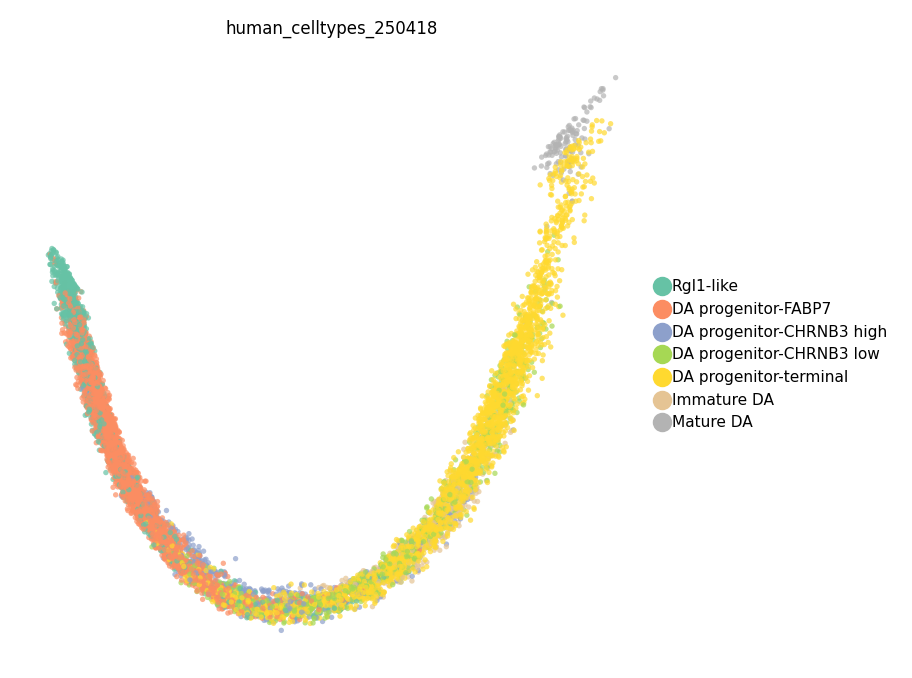

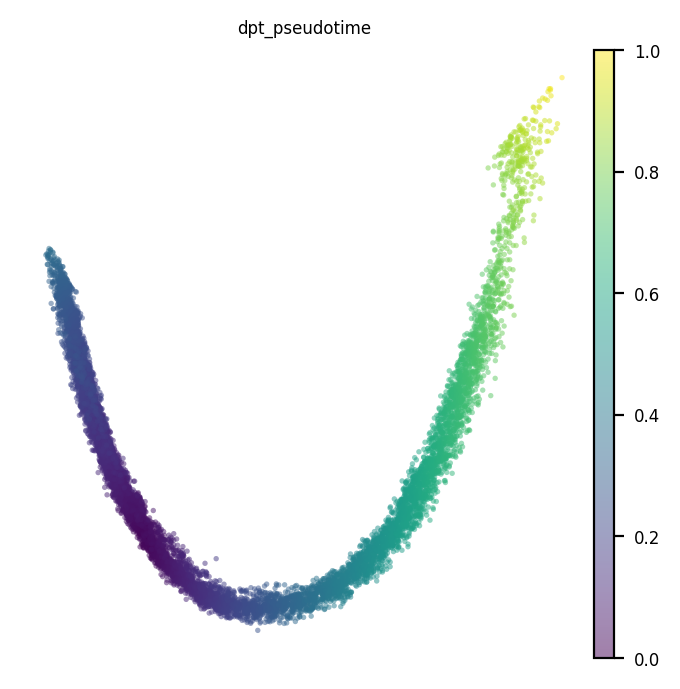

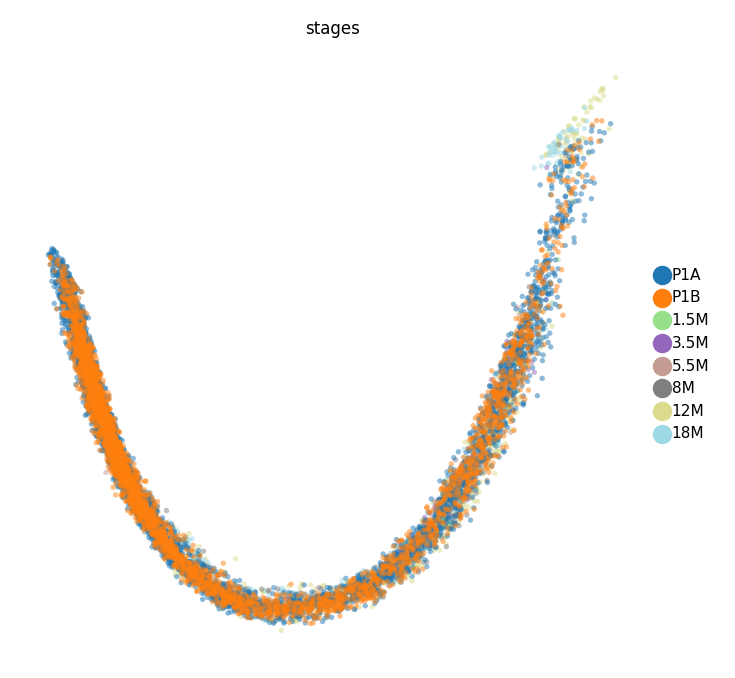

In [6]:
n_neighbors=10
n_pcs=5
n_comps=10
sc.pp.neighbors(
    adata_sub, 
    n_neighbors=n_neighbors, 
    n_pcs=n_pcs,  # 使用校正后的前30个PC
    use_rep='X_integrated.rpca' # 明确指定使用校正后的PCA
)
# 计算Diffusion Map和DPT伪时间
sc.tl.diffmap(adata_sub,n_comps=n_comps,random_state=42)
root_cell = adata_sub.obs['human_celltypes_250418'] == 'Rgl1-like'  # 设置根细胞类型
adata_sub.uns['iroot'] = np.where(root_cell)[0][0]  # 取第一个TypeA细胞作为根
sc.tl.dpt(adata_sub)
sc.pl.diffmap(
    adata_sub,
    color='human_celltypes_250418',
    components=('2,3'),  # 选关键扩散成分
    size=15,
    alpha=0.7,
    frameon=False,
    palette='Set2',  # 保证多类别颜色区分
    save=f'diffusionmap_celltype_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.pdf'
)
sc.pl.diffmap(
    adata_sub,
    color='dpt_pseudotime',
    components=('2,3'),  # 选关键扩散成分
    size=15,
    alpha=0.5,
    frameon=False,
    palette='Set2',  # 保证多类别颜色区分
    save=f'diffusionmap_pseudotime_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.pdf'
)
sc.pl.diffmap(
    adata_sub,
    color='stages',
    components=('2,3'),  # 选关键扩散成分
    size=15,
    alpha=0.5,
    frameon=False,
    palette='tab20',  # 保证多类别颜色区分
    save=f'diffusionmap_stages_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.pdf'
)

In [7]:
adata_sub

AnnData object with n_obs × n_vars = 11032 × 24190
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'seurat_clusters', 'prop_rat', 'prop_human', 'species', 'celltype', 'stages', 'new_resolution', 'final_resolution', 'final_resolution1', 'final_resolution2', 'final_resolution3', 'final_resolution4', 'celltype_new', 'qufen_celltype', 'dataset', 'sample', 'percent_MT', 'batch', 'human_celltypes', 'human_celltypes_250314', 'human_celltypes_250323', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'RNA_snn_res.1.3', 'RNA_snn_res.1.4', 'RNA_snn_res.1.5', 'RNA_snn_res.1.6', 'RNA_snn_res.1.7', 'RNA_snn_res.1.8', 'RNA_snn_res.1.9', 'RNA_snn_res.2', 'RNA_snn_res.2.1', 'RNA_snn_res.2.2', 'RNA_snn_res.2.3', 'RNA_snn_res.2.4', 'RNA_snn_res.2.5', 'RNA_snn_res.2.6', 'RNA_snn_res.2.7', 'RNA_snn_res.2.8', 'RNA_

In [8]:
adata_sub.write("scanpy_special_7cluster_celltypes_250418.h5ad")

In [136]:
sc.pl.diffmap(
    adata_sub,
    color='human_celltypes_250416',
    components=('2,3'),  # 选关键扩散成分
    size=15,
    alpha=0.7,
    frameon=False,
    palette='Set2',  # 保证多类别颜色区分
    save=f'diffusionmap_celltype_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.png'
)


In [83]:
from matplotlib import cm
import matplotlib.pyplot as plt

# 定义颜色和形状
celltypes = adata_sub.obs["human_celltypes_250416"].cat.categories.tolist()
colors = cm.get_cmap("Set2").colors[:len(celltypes)]  # 使用 Set2 调色板
grey_color = "#D3D3D3"  # 定义灰色

# 循环生成每个 stage 的高亮图
for i, target_celltype in enumerate(celltypes):
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 绘制所有其他 stage（灰色）
    mask_other = adata_sub.obs["human_celltypes_250416"] != target_celltype
    ax.scatter(
        adata_sub.obsm["X_diffmap"][mask_other, 1],  # X轴：DiffMap_2（索引1）
        adata_sub.obsm["X_diffmap"][mask_other, 2],  # Y轴：DiffMap_3（索引2）
        s=15,
        alpha=0.5,  # 更低的透明度避免遮挡
        color=grey_color,
        marker="o",
        linewidth=0,
        label=None  # 不显示图例
    )
    
    # 绘制当前 stage（高亮颜色）
    mask_target = adata_sub.obs["human_celltypes_250416"] == target_celltype
    ax.scatter(
        adata_sub.obsm["X_diffmap"][mask_target, 1],
        adata_sub.obsm["X_diffmap"][mask_target, 2],
        s=20,
        alpha=0.7,
        color=colors[i],
        marker="*",
       #edgecolor="black",
        linewidth=0.3,
        label=target_celltype
    )
    
    # 添加标题和图例
    ax.set_title(f"celltype Highlight: {target_celltype}", fontsize=12)
    ax.legend(loc="best", frameon=False)
    
    # 隐藏坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # 保存图片（文件名动态包含 stage 名称）
    plt.savefig(
        f'./figures/diffusionmap_celltype_{target_celltype}_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.pdf',
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()  # 关闭当前画布，避免内存泄漏


/tmp/ipykernel_3613787/3360767444.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("Set2").colors[:len(celltypes)]  # 使用 Set2 调色板


In [140]:
bright_colors = [
    "#FDC0F7","#D2D2D2","#9193B4","#E8D2B3",
    "#ADE0B4","#BDD1C6","#B12222","#82C61E"
]
sc.pl.diffmap(
    adata_sub,
    color='stages',
    components=('2,3'),  # 选关键扩散成分
    size=15,
    alpha=0.7,
    frameon=False,
    palette=bright_colors,  # 保证多类别颜色区分
    save=f'diffusionmap_stages_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.png'
)


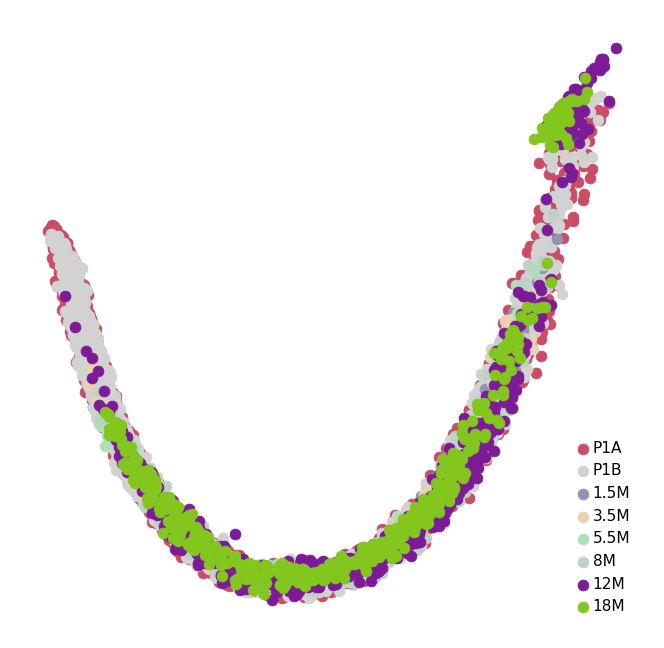

In [111]:
###stage其他画法
from matplotlib import cm
# 定义不同 stage 对应的标记符号
markers = [
    "o", "o", "o", "o", 
    "o", "o", "o", "o"  # 可根据需要替换或扩展
]

# 定义颜色（使用 'tab20' 调色板生成 8 种颜色）
bright_colors = [
    "#FDC0F7","#D2D2D2","#9193B4","#E8D2B3",
    "#ADE0B4","#BDD1C6","#B12222","#82C61E"
]

# 获取所有 stage 类别（按样本量排序）
stages = adata_sub.obs["stages"].cat.categories.tolist()
# 绘制
fig, ax = plt.subplots()
for i, stage in enumerate(stages):
    mask = adata_sub.obs["stages"] == stage
    ax.scatter(
        adata_sub.obsm["X_diffmap"][mask, 1],  # X 轴坐标
        adata_sub.obsm["X_diffmap"][mask, 2],  # Y 轴坐标
        label=stage,
        #marker=markers[i],            # 指定形状
        s=15,                             # 大小
        alpha=1,
        color=colors[i],  
        linewidth=0.3
    )
    # 隐藏坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
ax.legend(title="",loc="lower right",frameon=False)
plt.savefig(f'./figures/diffusionmap__stages_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}_1.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [127]:
from matplotlib import cm
import matplotlib.pyplot as plt

# 定义颜色和形状
stages = adata_sub.obs["stages"].cat.categories.tolist()
bright_colors = [
    "#FDC0F7","#D2D2D2","#9193B4","#E8D2B3",
    "#ADE0B4","#BDD1C6","#B12222","#82C61E"
]
grey_color = "#D3D3D3"  # 定义灰色

# 循环生成每个 stage 的高亮图
for i, target_stage in enumerate(stages):
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 绘制所有其他 stage（灰色）
    mask_other = adata_sub.obs["stages"] != target_stage
    ax.scatter(
        adata_sub.obsm["X_diffmap"][mask_other, 1],  # X轴：DiffMap_2（索引1）
        adata_sub.obsm["X_diffmap"][mask_other, 2],  # Y轴：DiffMap_3（索引2）
        s=15,
        alpha=0.2,  # 更低的透明度避免遮挡
        color=grey_color,
        marker="o",
        linewidth=0,
        label=None  # 不显示图例
    )
    
    # 绘制当前 stage（高亮颜色）
    mask_target = adata_sub.obs["stages"] == target_stage
    ax.scatter(
        adata_sub.obsm["X_diffmap"][mask_target, 1],
        adata_sub.obsm["X_diffmap"][mask_target, 2],
        s=20,
        alpha=0.7,
        color=bright_colors[i],
        marker="*",
        edgecolor="black",
        linewidth=0.3,
        label=target_stage
    )
    
    # 添加标题和图例
    ax.set_title(f"Stage Highlight: {target_stage}", fontsize=12)
    ax.legend(loc="best", frameon=False)
    
    # 隐藏坐标轴
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # 保存图片（文件名动态包含 stage 名称）
    plt.savefig(
        f'./figures/diffusionmap__stage_{target_stage}_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.close()  # 关闭当前画布，避免内存泄漏


In [56]:
adata_sub.var_names.tolist()[:20]

['DDX11L2',
 'MIR1302-2HG',
 'LINC01409',
 'FAM87B',
 'LINC00115',
 'LINC01128',
 'FAM41C',
 'LINC02593',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'PERM1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223',
 'C1orf159',
 'LINC01342',
 'TTLL10-AS1']

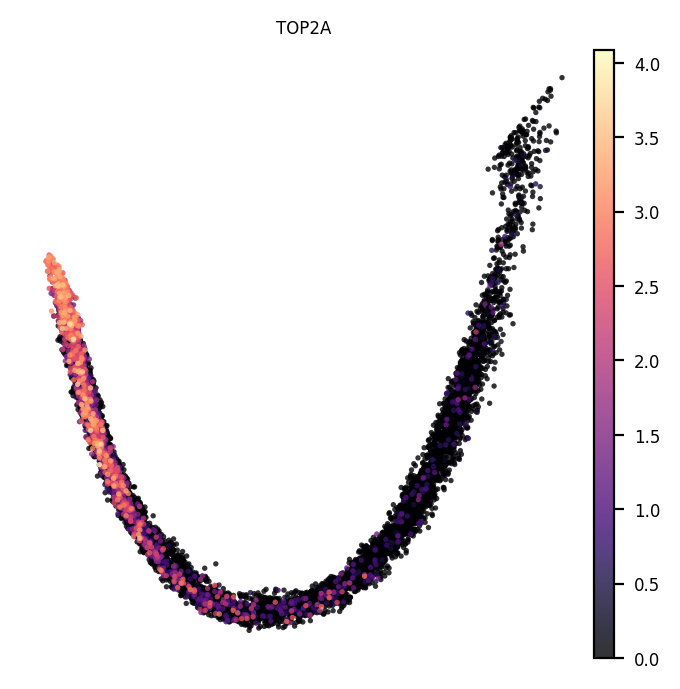

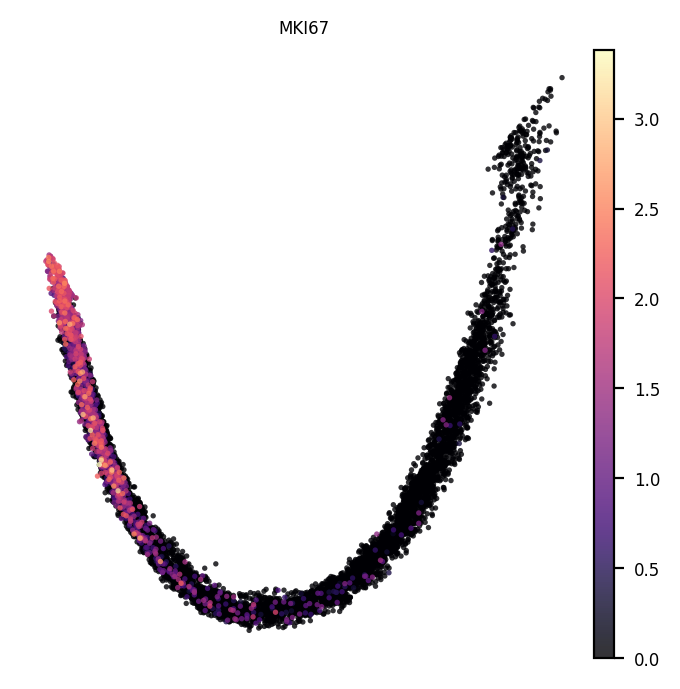

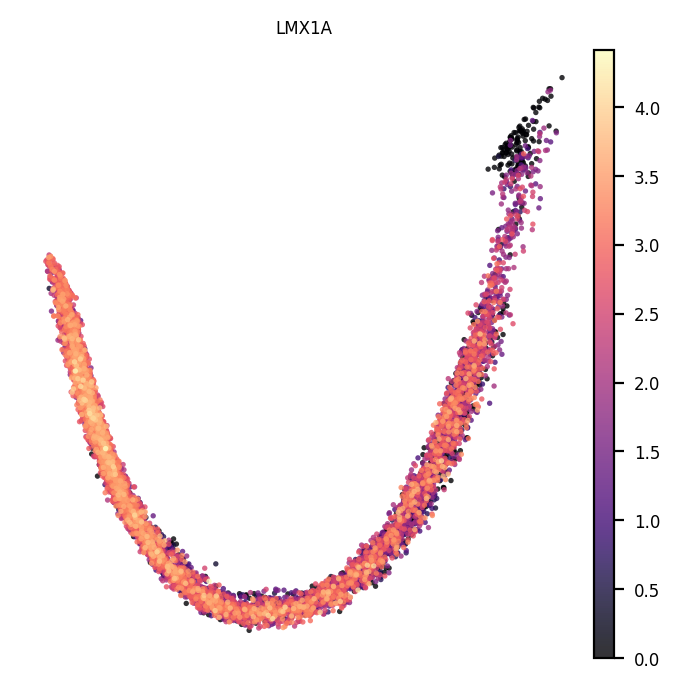

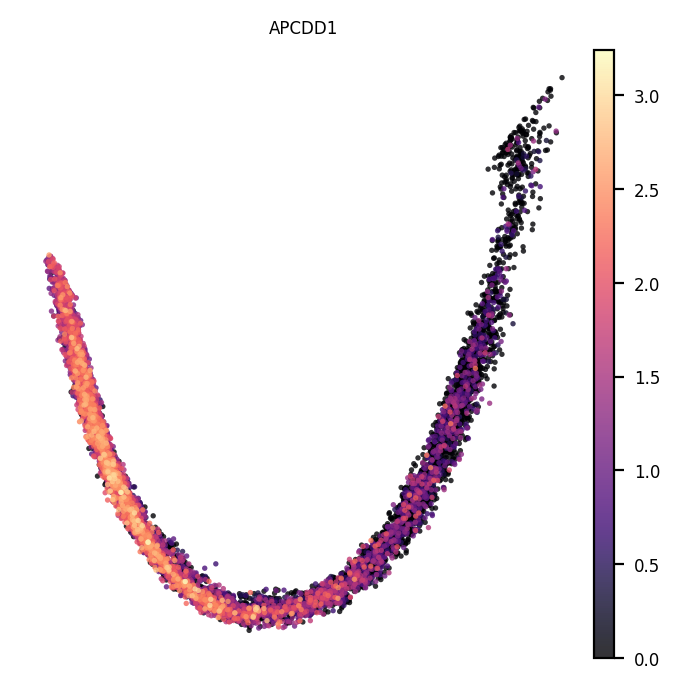

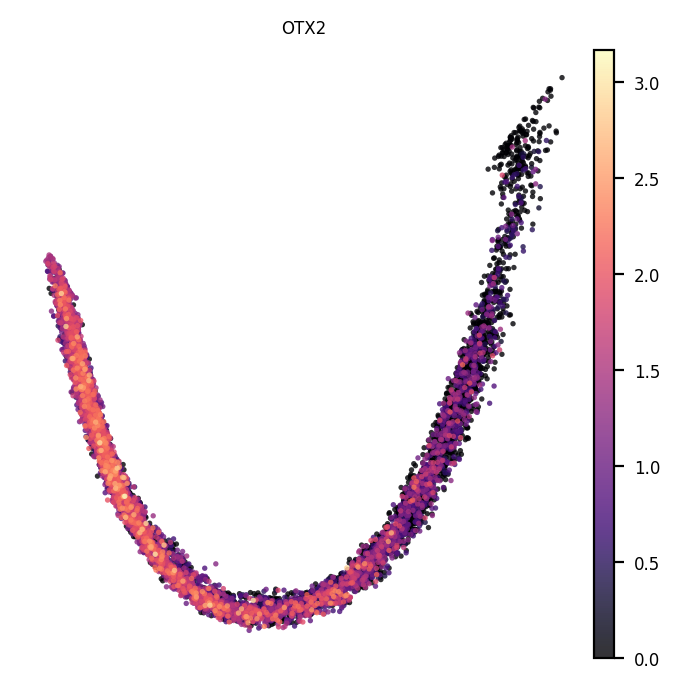

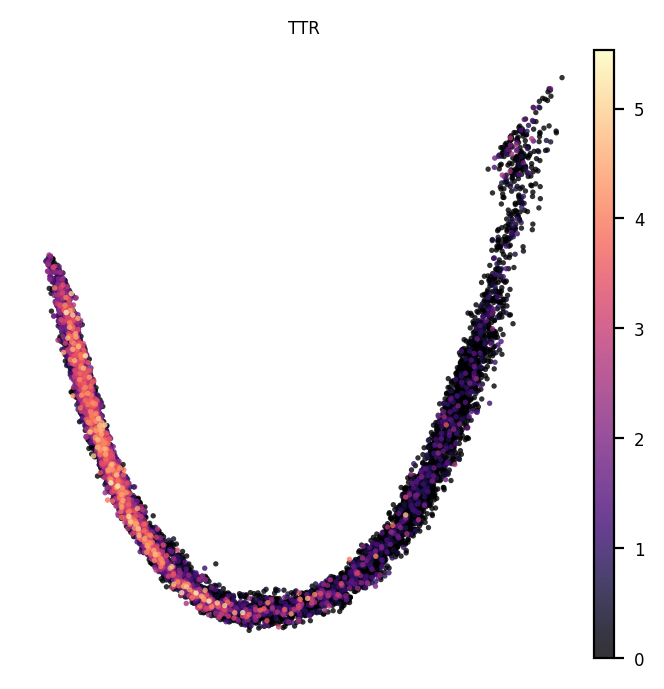

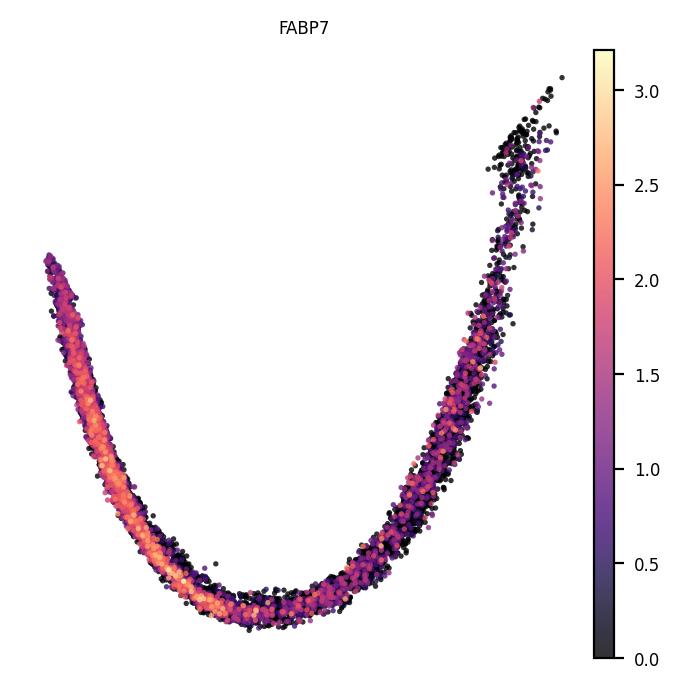

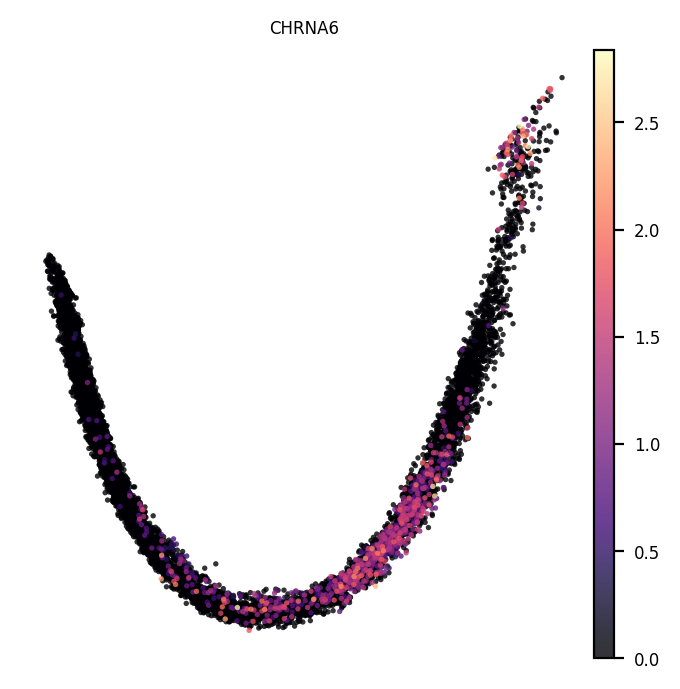

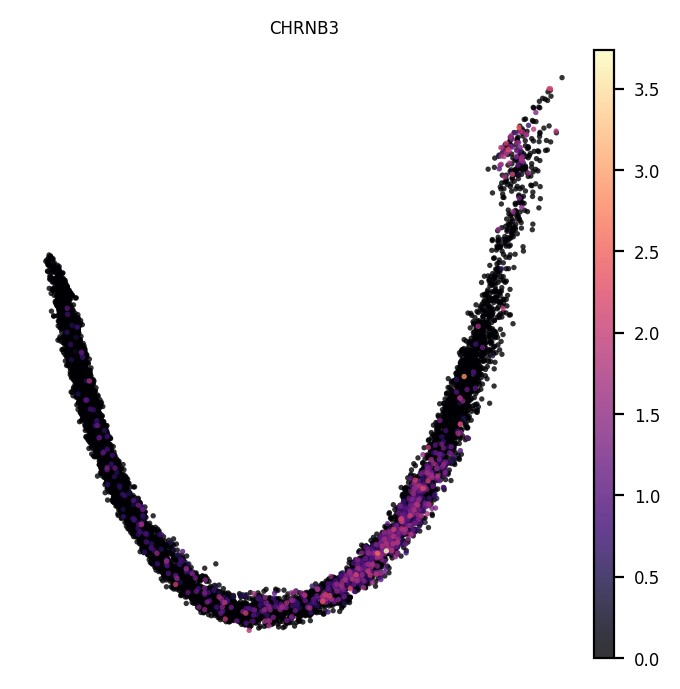

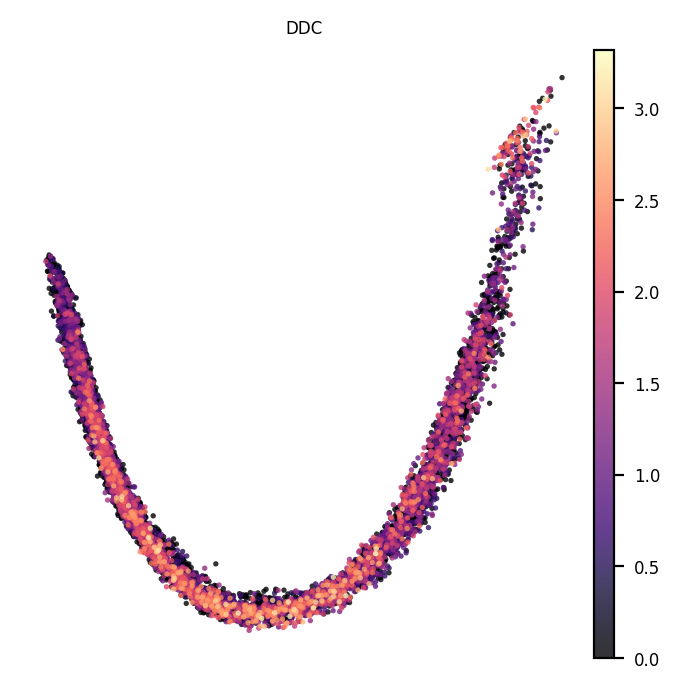

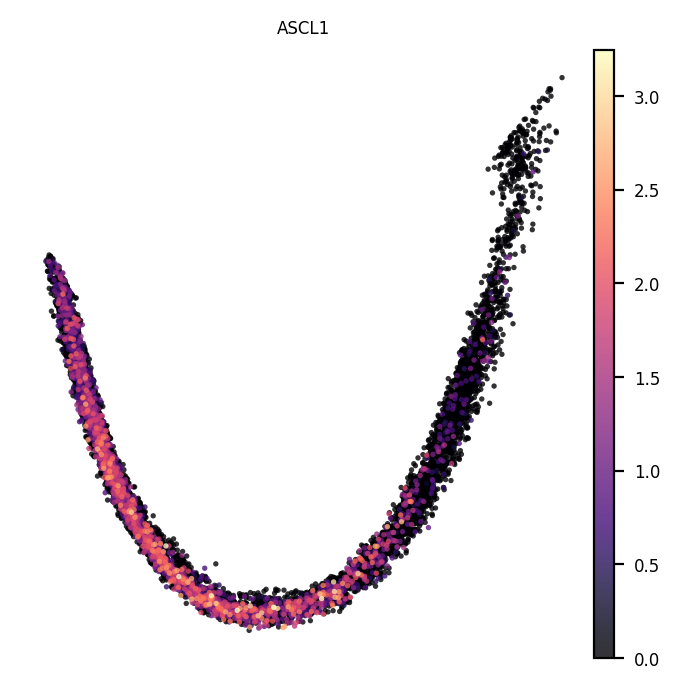

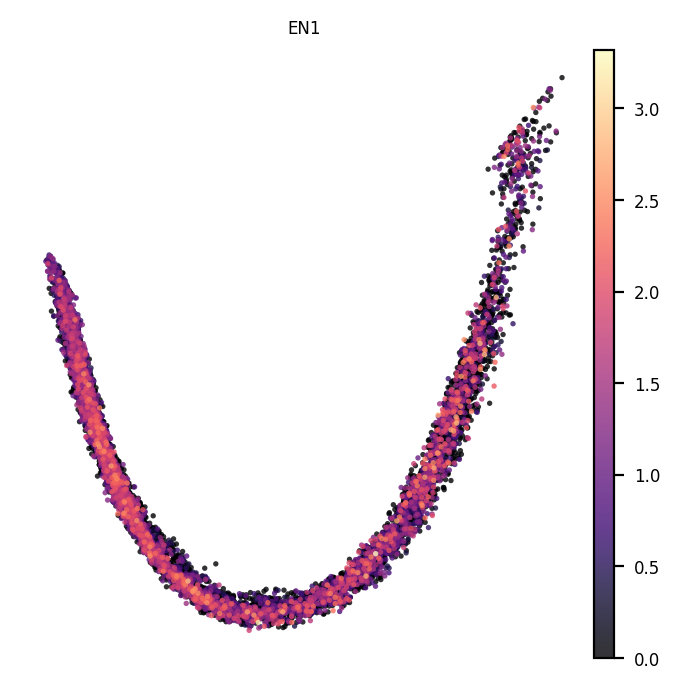

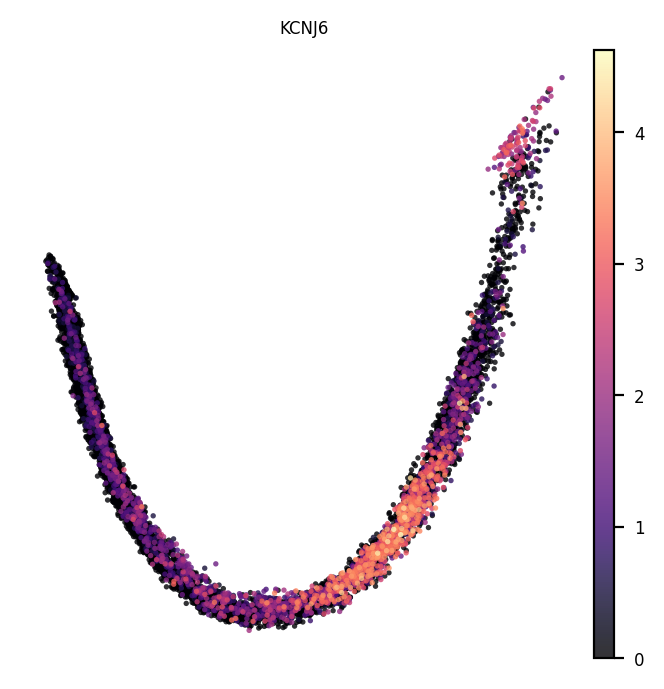

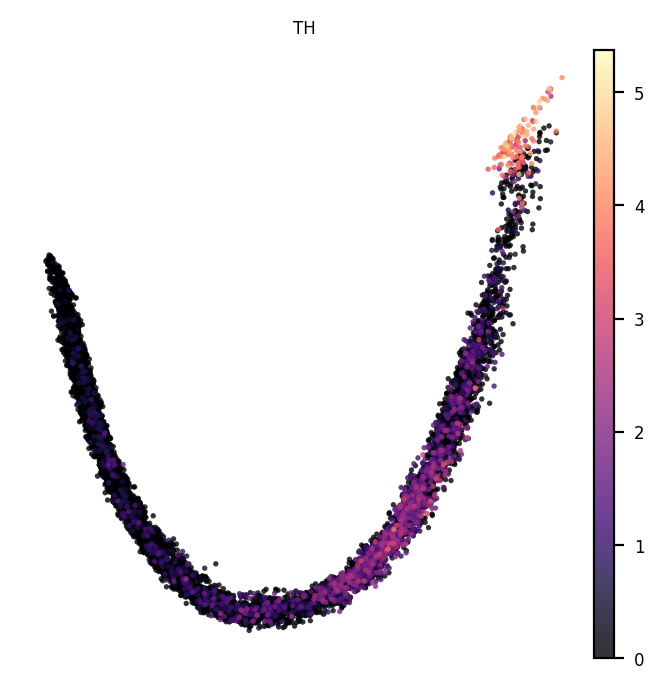

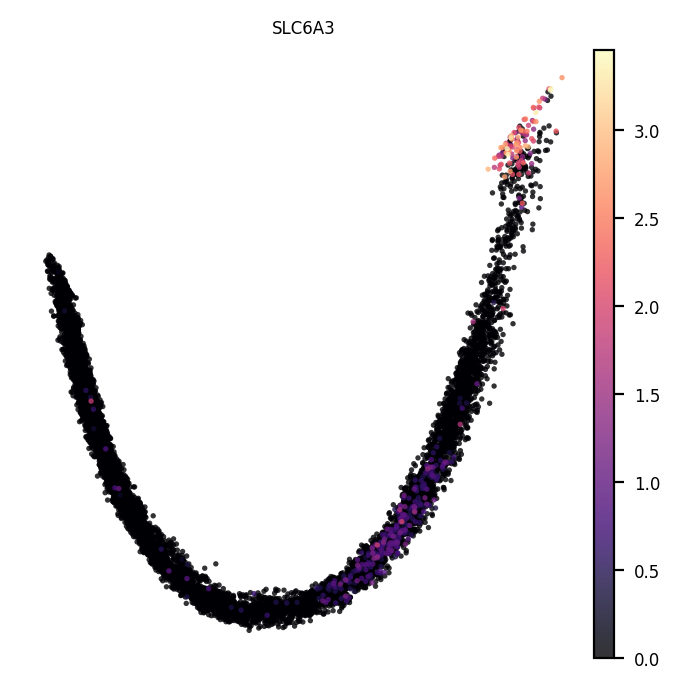

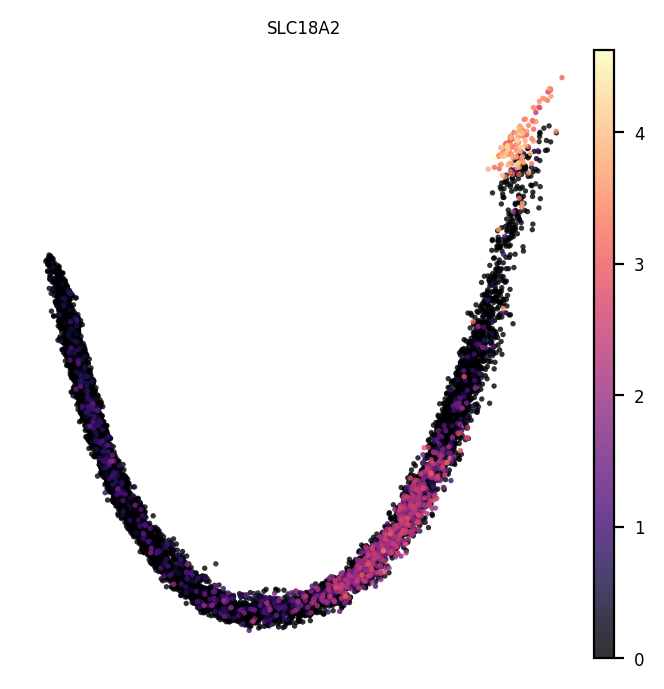

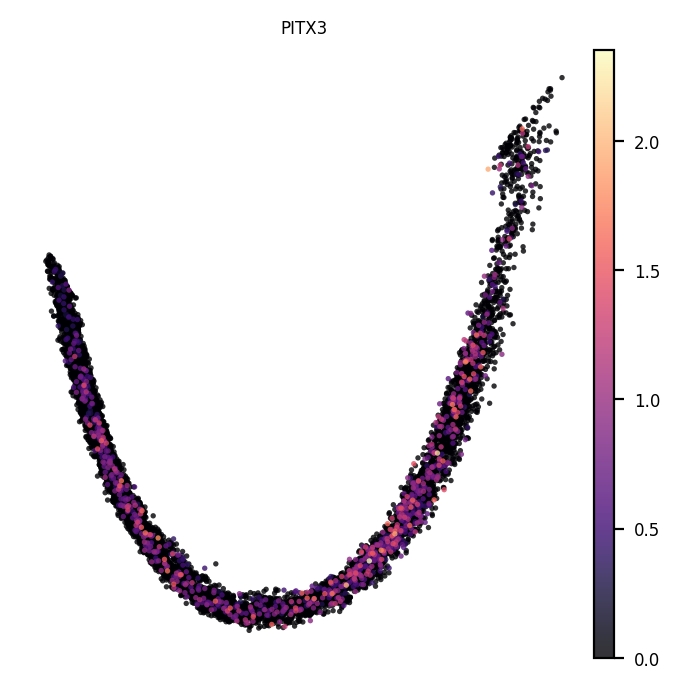

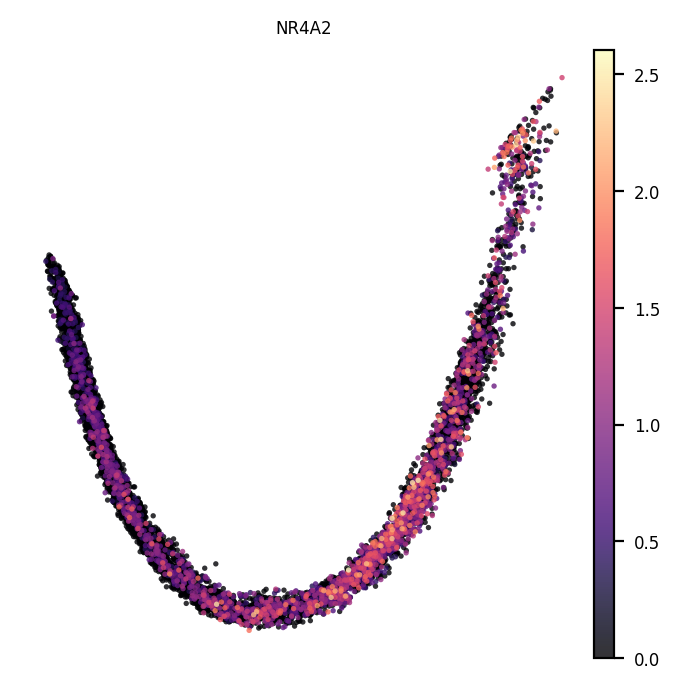

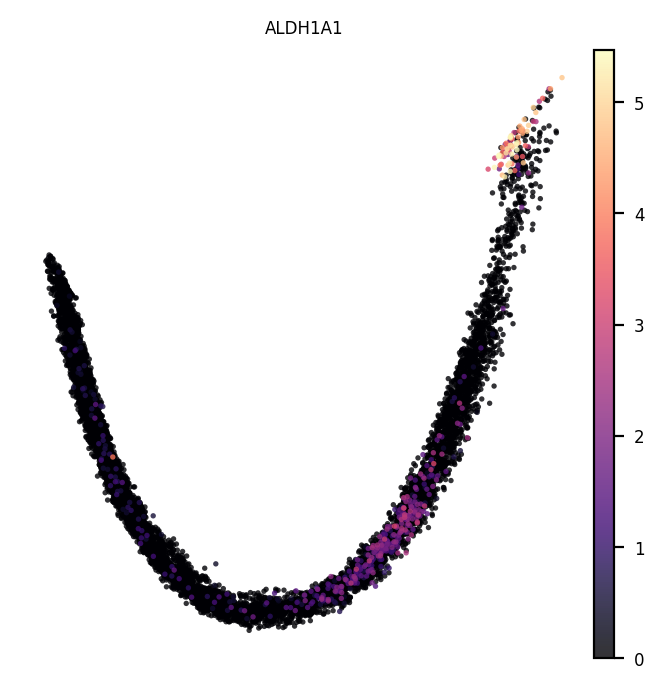

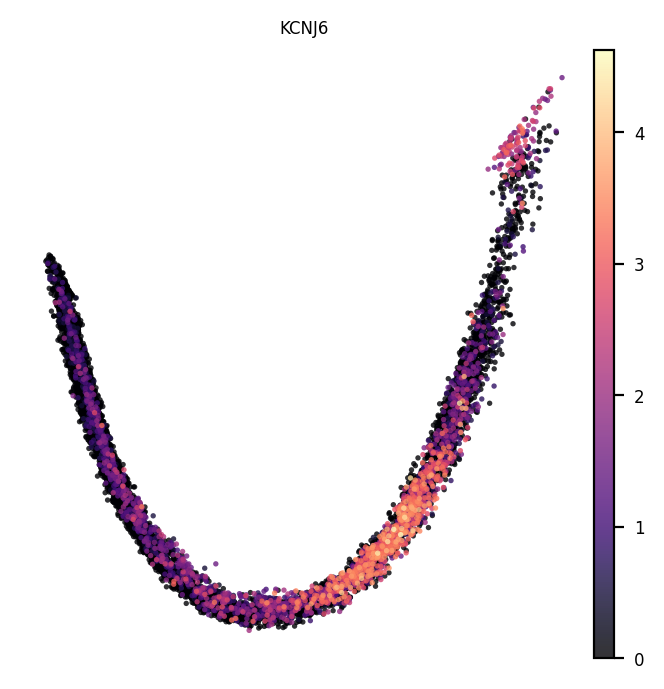

In [74]:
##不同基因作图
gene_lists=["top2a","mki67","Lmx1a","Apcdd1","OTX2","TTR","FABP7","CHRNA6","CHRNB3","DDC","ASCL1","EN1",
            "KCNJ6","TH","SLC6A3","SLC18A2","PITX3","NR4A2","ALDH1A1","KCNJ6"]
gene_lists = [gene.upper() for gene in gene_lists]  # 全大写
for gene in gene_lists:
    sc.pl.diffmap(
        adata_sub,
        color=gene,
        components=('2,3'),  # 选关键扩散成分
        size=15,
        alpha=0.8,
        frameon=False,
        cmap='magma',  # 保证多类别颜色区分
        save=f'diffusionmap_gene{gene}_n_neighbors{n_neighbors}_n_pcs{n_pcs}_n_comps{n_comps}.pdf'  
    )


In [ ]:
import itertools  # 用于生成参数组合

# 定义待测试的参数范围
n_pcs_list = list(range(10, 30))        # 测试不同的 n_pcs 值
min_dist_list = np.round(np.arange(0.1, 0.7, 0.2),1)  # UMAP 的 min_dist 参数
spread_list = np.round(np.arange(0.5, 3, 0.5),1)   # UMAP 的 spread 参数

# 遍历所有参数组合
for n_pcs, min_dist, spread in itertools.product(n_pcs_list, min_dist_list, spread_list):
    # 复制原始数据，避免覆盖原有结果
    adata_temp = adata_sub.copy()
    
    # Step 1: 计算邻居图（使用当前 n_pcs）
    sc.pp.neighbors(
        adata_temp,
        n_neighbors=10,
        n_pcs=n_pcs,
        use_rep='X_integrated.rpca'  # 确保使用已校正的 PCA
    )
    
    # Step 2: 计算 UMAP（应用当前 min_dist 和 spread）
    sc.tl.umap(
        adata_temp,
        min_dist=min_dist,
        spread=spread
    )
    
    # Step 3: 绘制 UMAP 图并标注参数
    sc.pl.umap(
        adata_temp,
        color='human_celltypes_250416',
        palette='Set2',
        title=f'n_pcs={n_pcs}, min_dist={min_dist}, spread={spread}',  # 标题显示参数
        legend_loc='on data',
        legend_fontsize=10,
        legend_fontoutline=2,
        frameon=False,
        show=False  # 避免自动显示，便于批量保存
    )
    
    # 可选：保存图片到文件
    plt.savefig(f'./test_figures/UMAP_npcs{n_pcs}_mindist{min_dist}_spread{spread}.png', dpi=300, bbox_inches='tight')
    plt.close()  # 关闭当前图像，释放内存